In [1]:
import kagglehub

# Download the latest version of the dataset from KaggleHub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [2]:
import pandas as pd

# Load the Mall_Customers.csv file into a pandas DataFrame
df = pd.read_csv(path + "/Mall_Customers.csv")

# Display the first few rows of the DataFrame to inspect the data
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


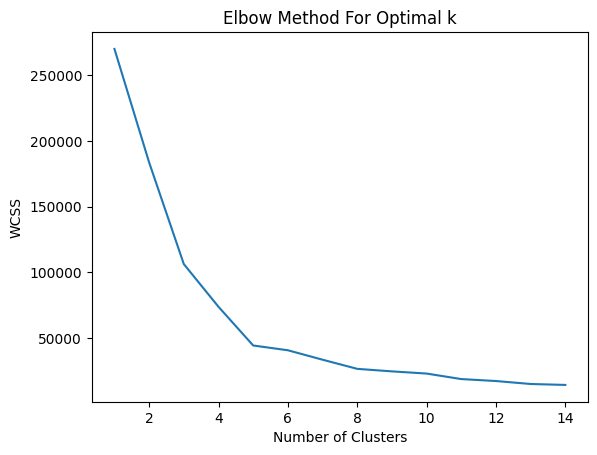

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize an empty list to store Within-Cluster Sum of Squares (WCSS) values
wcss = []

# Select the features for clustering: 'Annual Income (k$)' and 'Spending Score (1-100)'
X = df[['Annual Income (k$)','Spending Score (1-100)']]

# Iterate from 1 to 14 clusters to calculate WCSS for each number of clusters
for i in range(1,15):
  # Initialize KMeans with 'i' clusters and a fixed random state for reproducibility
  kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
  # Fit the KMeans model to the data
  kmeans.fit(X)
  # Append the inertia (WCSS) to the list
  wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1,15),wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method For Optimal k")
plt.show()

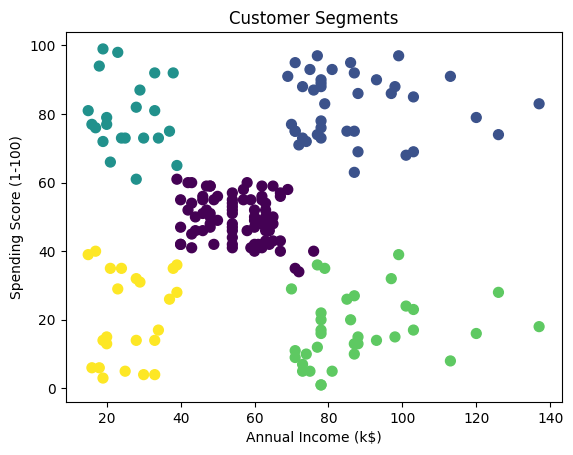

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [4]:
import matplotlib.pyplot as plt

# Apply KMeans clustering with 5 clusters (determined from the elbow method)
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')

# Predict the cluster for each data point
y_kmeans = kmeans.fit_predict(X)

# Create a scatter plot of the clusters
# 'c=y_kmeans' colors points based on their assigned cluster
# 's=50' sets the size of the markers
# 'cmap='viridis'' sets the colormap
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=y_kmeans, s=50, cmap='viridis')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

# Print the coordinates of the cluster centers
print(kmeans.cluster_centers_)

In [5]:
# Add the cluster assignments as a new column to the DataFrame
df['Cluster'] = y_kmeans

# Display the first few rows of the DataFrame with the new 'Cluster' column
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [6]:
# Group the DataFrame by 'Cluster' and calculate the mean of 'Annual Income (k$)' and 'Spending Score (1-100)' for each cluster
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()

# Display the summary of each cluster
display(cluster_summary)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Customer Segment Insights:

Based on the K-Means clustering, we've identified 5 distinct customer segments:

*   **Cluster 1 (Average Shoppers):** These customers have a balanced annual income and spending score, representing the everyday customer base.
*   **Cluster 2 (High-Value Spenders):** This segment consists of customers with high annual income and high spending scores. They are likely your most valuable customers, ideal for premium product offerings and loyalty programs.
*   **Cluster 3 (Impulse Buyers / Young Adults):** Characterized by lower annual income but high spending scores, this group might be more prone to impulse purchases or younger customers with developing spending habits. They could be targeted with trendy or value-for-money products.
*   **Cluster 4 (Careful High Earners):** These customers have a high annual income but a low spending score, suggesting they are careful with their expenditures or highly selective. Marketing efforts could focus on long-term value, quality, or investment-type products.
*   **Cluster 5 (Budget-Conscious):** With both low annual income and low spending scores, these customers are likely very budget-conscious. Promotions, discounts, and essential goods would resonate well with this segment.